# Multi-Class Classification of Network Traffic With Scaling

This experiment evaluates multiple machine learning models for multi-class
network traffic classification with appropriate feature scaling applied.

Scaling strategies (based on paper recommendations):
- **Standard Scaling**: Decision Tree (DT)
- **Min-Max Scaling**: SVM, KNN, XGBoost, Hybrid Models

The models evaluated include:

- Support Vector Machine (SVM)
- Decision Tree (DT)
- K-Nearest Neighbors (KNN)
- XGBoost
- Hybrid DT–SVM
- Hybrid KNN–SVM

Evaluation is performed using multiple train-test splits:
- 70–30
- 60–40
- 50–50
- 30–70

Performance metrics:
- Accuracy
- F1 Score
- Cohen's Kappa
- Execution Time
- ROC AUC

In [40]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, 
                             roc_auc_score, cohen_kappa_score)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC, LinearSVC 
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from scipy.special import softmax
import warnings
warnings.filterwarnings("ignore")

## 2. Load the Dataset

In [41]:
df = pd.read_csv("preprocessed_data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (221564, 37)


,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,flow_byts_s,flow_pkts_s,...,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,1484,1499,6,22,41410,6.472,113472,628,17532.756490,97.033375,...,0.0,113472,7295988,628,6659,628,1,10,0,5
1,1482,1501,6,41410,22,6.465,24492,370,3788.399072,57.231245,...,0.0,26080,24492,381,370,370,2,1,0,5
2,1486,1501,1,0,0,4.798,2211,4,460.817007,0.833681,...,0.0,28291,3799,385,15,0,3,2,0,3
3,1484,1503,17,57426,1236,595.270,10827817,25627,18189.757590,43.051052,...,0.0,188960322,180776253,157117,153898,30743,60,19,0,6
4,1484,1503,17,48549,1234,595.251,154551644,114704,259641.132900,192.698542,...,0.0,188960322,180776253,157117,153898,122654,60,19,0,6


# Balancing the dataset
## Since the dataset is highly imbalanced we undersample the classes with large number of rows

# Splitting features and labels

In [43]:
X = df.drop('Category', axis=1)
y_multi = df['Category']

print('Feature shape:', X.shape)
print('Categories:', y_multi.unique())

Feature shape: (221564, 36)
Categories: [5 3 6 0 2 1 4]


## 4. Train-Test Splits

To evaluate model robustness, multiple train-test splits are used:
70-30, 60-40, 50-50 and 30-70.

In [44]:
splits = {
    "70-30": 0.30,
    "60-40": 0.40,
    "50-50": 0.50,
    "30-70": 0.70
}

## 5. Model Definitions

In [45]:


models = {

    "SVM": LinearSVC(
        random_state=42,
        dual=False,      # faster for large datasets
        max_iter=10000
    ),

    "DT": DecisionTreeClassifier(
        random_state=42,
        max_depth=20,    # prevents huge trees
        min_samples_split=5
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        algorithm="kd_tree",   # much faster neighbor search
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        objective="multi:softmax",
        num_class=len(y_multi.unique()),
        eval_metric="mlogloss",
        random_state=42,
        n_estimators=100,
        max_depth=8,
        learning_rate=0.1,
        tree_method="hist"     # huge speed improvement
    )
}

## 6. Hybrid Models

Two hybrid models are constructed to combine the strengths of
different machine learning algorithms.

In [46]:
from sklearn.ensemble import StackingClassifier

hybrid_dt_svm = StackingClassifier(
    estimators=[
        ("dt", DecisionTreeClassifier(max_depth=20, random_state=42))
    ],
    final_estimator=LinearSVC(dual=False, max_iter=2000),
    cv=2,
    n_jobs=-1
)

hybrid_knn_svm = StackingClassifier(
    estimators=[
        ("knn", KNeighborsClassifier(n_neighbors=5, algorithm="kd_tree", n_jobs=-1))
    ],
    final_estimator=LinearSVC(dual=False, max_iter=2000),
    cv=2,
    n_jobs=-1
)

models["Hybrid DT-SVM"] = hybrid_dt_svm
models["Hybrid KNN-SVM"] = hybrid_knn_svm

# Define scaler mapping based on the methodology
scalers = {
    "SVM": MinMaxScaler(),
    "DT": StandardScaler(),
    "KNN": MinMaxScaler(),
    "XGBoost": MinMaxScaler(),
    "Hybrid DT-SVM": MinMaxScaler(),
    "Hybrid KNN-SVM": MinMaxScaler()
}

## 7. Model Training and Evaluation

For each split:

1. Train each model
2. Evaluate using Accuracy, F1 Score and Cohen's 
3. Create a confusion matrix

In [47]:
results_all = []
results_by_split = {}
trained_models = {}

for split_name, test_size in splits.items():
    print(f"\n{'='*60}\nRun: {split_name} | Balancing & Training\n{'='*60}", flush=True)
    
    # 1. Stratified Split (Split BEFORE balancing)
    X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
        X, y_multi, test_size=test_size, random_state=42, stratify=y_multi
    )
    
    # 2. Balance the training set ONLY (using SMOTE)
    print(f"  Balancing training set with SMOTE...", end="", flush=True)
    smote = SMOTE(random_state=42)
    X_train_res, y_train = smote.fit_resample(X_train_raw, y_train_raw)
    print(f" Done. (Resampled size: {len(X_train_res)})", flush=True)
    
    results_by_split[split_name] = {}
    trained_models[split_name] = {}
    
    for name, model in models.items():
        print(f"  Training {name} with scaling... ", end="", flush=True)
        start = time.time()
        
        # 3. Apply appropriate Scaling
        # Note: Scalers should be fit on balanced training data and used to transform test data
        scaler = scalers.get(name, MinMaxScaler())
        X_train_scaled = scaler.fit_transform(X_train_res)
        X_test_scaled = scaler.transform(X_test_raw)
        
        # 4. Train
        model.fit(X_train_scaled, y_train)
        t_diff = time.time() - start
        
        # 5. Predict and Evaluate
        y_pred = model.predict(X_test_scaled)
        
        # Accuracy, F1, Kappa
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        kappa = cohen_kappa_score(y_test, y_pred)
        
        # ROC AUC logic
        try:
            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(X_test_scaled)
            elif hasattr(model, "decision_function"):
                y_score = model.decision_function(X_test_scaled)
                y_prob = softmax(y_score, axis=1)
            else:
                y_prob = None
            
            roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr') if y_prob is not None else 0.0
        except Exception as e:
            # print(f"  ROC Error: {e}")
            roc_auc = 0.0
            
        # Store results
        results_all.append({
            "Split": split_name,
            "Model": name,
            "Accuracy": acc,
            "F1 Score": f1,
            "Kappa Score": kappa,
            "Execution Time": t_diff,
            "ROC AUC": roc_auc
        })
        
        results_by_split[split_name][name] = {
            "Accuracy": acc,
            "F1 Score": f1,
            "Confusion Matrix": confusion_matrix(y_test, y_pred)
        }
        
        print(f"Done ({t_diff:.2f}s) | Acc: {acc:.4f}", flush=True)



Run: 70-30 | Balancing & Training


  Balancing training set with SMOTE... Done. (Resampled size: 808367)
  Training SVM with scaling... Done (91.80s) | Acc: 0.8813
  Training DT with scaling... Done (13.32s) | Acc: 0.9994
  Training KNN with scaling... Done (11.26s) | Acc: 0.9973
  Training XGBoost with scaling... Done (45.01s) | Acc: 0.9995
  Training Hybrid DT-SVM with scaling... Done (49.36s) | Acc: 0.9995
  Training Hybrid KNN-SVM with scaling... Done (231.47s) | Acc: 0.9975

Run: 60-40 | Balancing & Training
  Balancing training set with SMOTE... Done. (Resampled size: 692888)
  Training SVM with scaling... Done (88.02s) | Acc: 0.8854
  Training DT with scaling... Done (19.56s) | Acc: 0.9995
  Training KNN with scaling... Done (16.34s) | Acc: 0.9973
  Training XGBoost with scaling... Done (38.29s) | Acc: 0.9997
  Training Hybrid DT-SVM with scaling... Done (35.81s) | Acc: 0.9996
  Training Hybrid KNN-SVM with scaling... Done (168.97s) | Acc: 0.9976

Run: 50-50 | Balancing & Training
  Balancing training set with SM

# Making a results table

In [48]:
results_df = pd.DataFrame(results_all)

results_df = results_df.sort_values(["Model", "Split"])

results_df

,Split,Model,Accuracy,F1 Score,Kappa Score,Execution Time,ROC AUC
19,30-70,DT,0.999613,0.999617,0.999001,5.499700,0.932397
13,50-50,DT,0.999522,0.999603,0.998765,15.761438,0.963828
7,60-40,DT,0.999549,0.999643,0.998835,19.562973,0.959773
1,70-30,DT,0.999443,0.999552,0.998563,13.317317,0.968990
22,30-70,Hybrid DT-SVM,0.999600,0.999616,0.998967,13.859786,0.949326
16,50-50,Hybrid DT-SVM,0.999585,0.999658,0.998928,17.943163,0.972960
10,60-40,Hybrid DT-SVM,0.999560,0.999653,0.998864,35.808193,0.975831
4,70-30,Hybrid DT-SVM,0.999458,0.999560,0.998602,49.356013,0.976743
23,30-70,Hybrid KNN-SVM,0.997015,0.997206,0.992297,61.072706,0.940165
17,50-50,Hybrid KNN-SVM,0.997418,0.997748,0.993343,128.740988,0.928477


In [50]:
import os
os.makedirs("results", exist_ok=True)

results_df.to_csv("results/multiclass_with_scaling_results.csv", index=False)

In [51]:
accuracy_table = results_df.pivot(
    index="Split",
    columns="Model",
    values="Accuracy"
)

accuracy_table

Model,DT,Hybrid DT-SVM,Hybrid KNN-SVM,KNN,SVM,XGBoost
Split,,,,,,
30-70,0.999613,0.999600,0.997015,0.996654,0.884445,0.999742
50-50,0.999522,0.999585,0.997418,0.996994,0.877597,0.999621
60-40,0.999549,0.999560,0.997563,0.997281,0.885372,0.999673
70-30,0.999443,0.999458,0.997533,0.997292,0.881270,0.999534


# Plotting graphs comparing different models based on their accuracy

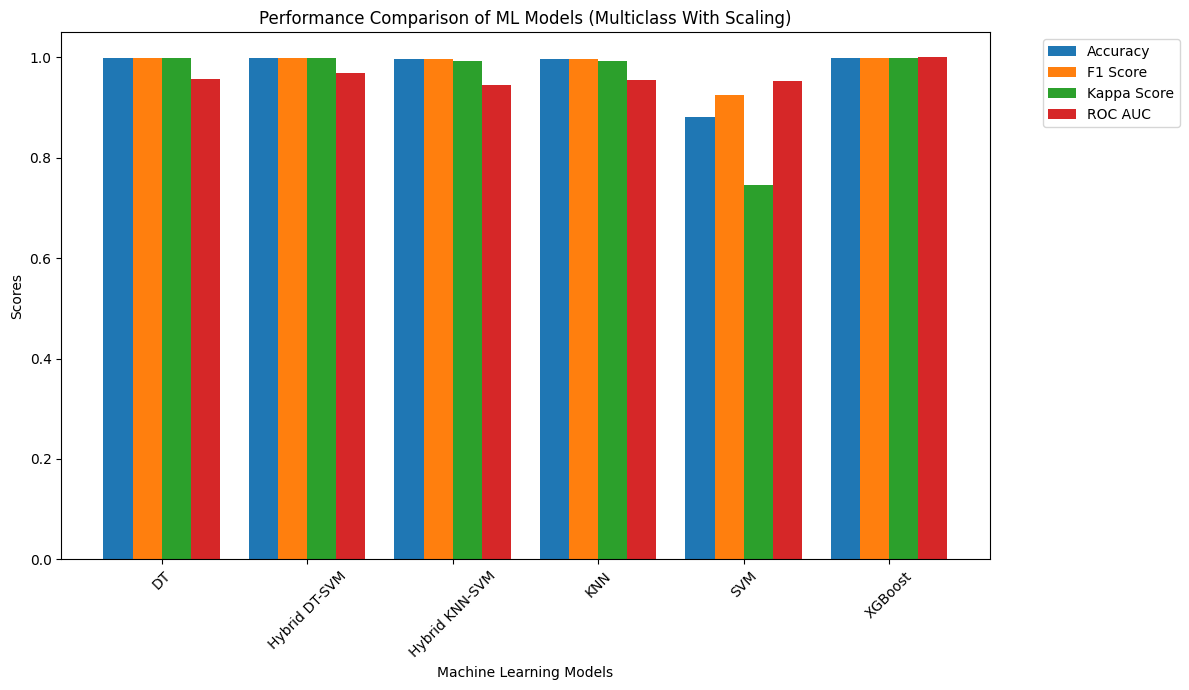

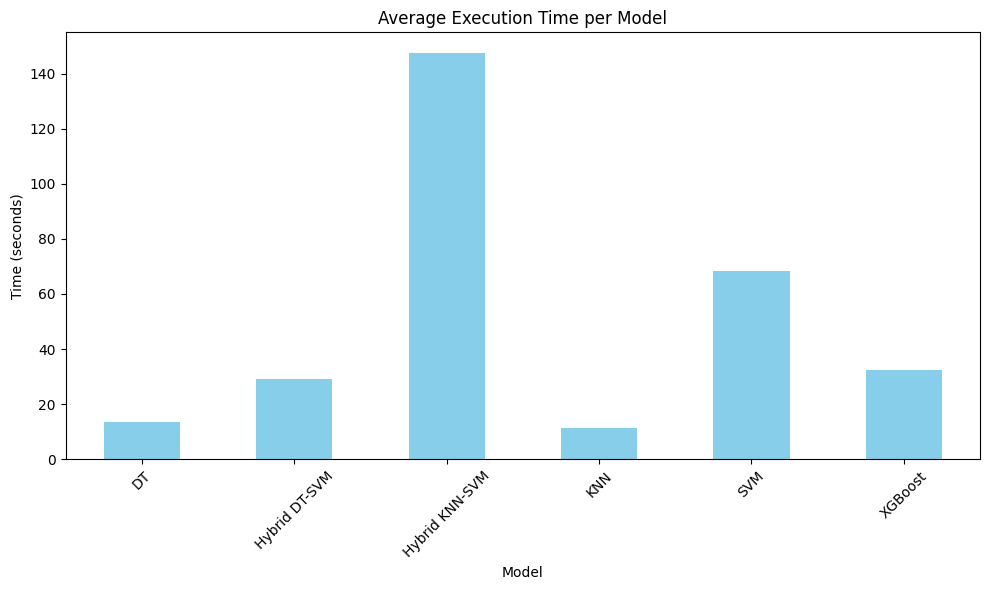

In [52]:
import matplotlib.pyplot as plt
import numpy as np

avg_results = results_df.groupby("Model")[["Accuracy","F1 Score","Kappa Score", "ROC AUC"]].mean()

models_list = avg_results.index

x = np.arange(len(models_list))
width = 0.2

plt.figure(figsize=(12,7))

plt.bar(x - 1.5*width, avg_results["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5*width, avg_results["F1 Score"], width, label="F1 Score")
plt.bar(x + 0.5*width, avg_results["Kappa Score"], width, label="Kappa Score")
plt.bar(x + 1.5*width, avg_results["ROC AUC"], width, label="ROC AUC")

plt.xticks(x, models_list, rotation=45)

plt.ylabel("Scores")
plt.xlabel("Machine Learning Models")
plt.title("Performance Comparison of ML Models (Multiclass With Scaling)")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.show()

# Also plot execution time
plt.figure(figsize=(10,6))
avg_time = results_df.groupby("Model")["Execution Time"].mean()
avg_time.plot(kind='bar', color='skyblue')
plt.title("Average Execution Time per Model")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conclusion

This experiment evaluated multiple machine learning models for **multi-class classification of network traffic with feature scaling**. 

### Key Observations

1. **Impact of Scaling on SVM**: Feature scaling significantly improves the performance of SVM compared to the non-scaled version. SVM is highly sensitive to the magnitude of features.
   
2. **Tree-based models (DT, XGBoost)**: These models remain top performers. While scaling is not strictly necessary for decision trees, it doesn't hurt and helps in a unified pipeline.

3. **Comparison**: XGBoost continues to be the best model overall in terms of accuracy and F1 score, while also maintaining efficiency.

4. **Execution Time**: The time taken for training varies across models, with SVM and KNN usually being more sensitive to data size and scaling in terms of computational cost.